# NICE on MNIST
This notebook implements the NICE MNIST experiment in NumPy/vectorized micrograd, keeping the data handling close to the supplied MATLAB setup while using MATLAB/NICE-style RMSProp with momentum for parity:

- training uses the first 50,000 MNIST training images;
- validation uses the next 10,000 MNIST training images with fixed dequantization seed `1234`;
- test uses the MNIST test split with fixed dequantization seed `5678`;
- minibatches are freshly dequantized every update, like MATLAB;
- coupling partitions are MATLAB/NICE odd/even vector components;
- training uses Pylearn2/NICE-style RMSPropMomentum with `rho=0.95`, denominator floor `eps=1e-2`, exponential LR decay, and the MATLAB momentum schedule.

In [1]:
from pathlib import Path
import sys

# Make imports work whether the notebook is in the repo root or in examples/.
CWD = Path.cwd().resolve()
candidates = [CWD, CWD.parent]

for root in candidates:
    if (root / "vect_micrograd").exists():
        if str(root) not in sys.path:
            sys.path.insert(0, str(root))
        PROJECT_ROOT = root
        break
else:
    raise RuntimeError(
        "Could not find the vect_micrograd package. "
        "Open this notebook from the project root or move it into the project."
    )

print("Project root:", PROJECT_ROOT)


Project root: /home/r00t/vect_micrograd_flows


In [2]:
import gzip
import urllib.request
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

from vect_micrograd.flows import (
    AdditiveCoupling,
    DiagonalScaling,
    FlowSequential,
    NormalizingFlow,
    Permute,
    make_prior,
)
from vect_micrograd.optim import RMSProp, epoch_momentum
from vect_micrograd.vect_engine import Value
from vect_micrograd.utils import (
    clip_grad_norm,
    full_nll,
    grad_global_norm,
    load_state,
    save_state,
)

np.set_printoptions(precision=4, suppress=True)


## Configuration

In [3]:
seed = 1

image_size = 28
train_count = 50_000
validation_count = 10_000
train_subset = None      # set to e.g. 4096 only for smoke tests
valid_subset = None      # set to e.g. 4096 only for quicker validation
center_to_minus_one_one = False 

full_paper_style_run = False
hidden_units = 1000 if full_paper_style_run else 700
num_hidden_layers = 5
hidden_sizes = tuple([hidden_units] * num_hidden_layers)
num_coupling_layers = 4
prior = "logistic"

initial_partition = "odd_even"
permutation_between_layers = "none"
init_irange = 0.01

epochs = 1500 if full_paper_style_run else 250
batch_size = 200
learning_rate = 1e-3
log_every_steps = 50
validation_every_epochs = 1

# MATLAB/Pylearn2-style RMSPropMomentum settings used by the NICE code.
rmsprop_rho = 0.95
rmsprop_eps = 1e-2
rmsprop_eps_mode = "max"      # denominator is max(sqrt(avg_grad_sq), eps)
rmsprop_weight_decay = 0.0
min_learning_rate = 1e-4
lr_decay_factor = 1.0005      # per-update exponential decay until min_learning_rate
init_momentum = 0.0
final_momentum = 0.5
momentum_start_epoch = 5
momentum_saturate_epoch = 6

# Stabilizers. 
use_grad_clip = False
max_grad_norm = np.inf
abort_on_non_finite = True
restore_best_model = True



## MNIST loading and MATLAB-style dequantization

In [4]:
def _read_idx_images(path):
    with gzip.open(path, "rb") as f:
        data = f.read()
    magic = int.from_bytes(data[0:4], "big")
    if magic != 2051:
        raise ValueError(f"{path} is not an IDX image file")
    n = int.from_bytes(data[4:8], "big")
    rows = int.from_bytes(data[8:12], "big")
    cols = int.from_bytes(data[12:16], "big")
    arr = np.frombuffer(data, dtype=np.uint8, offset=16)
    return arr.reshape(n, rows, cols)


def _read_idx_labels(path):
    with gzip.open(path, "rb") as f:
        data = f.read()
    magic = int.from_bytes(data[0:4], "big")
    if magic != 2049:
        raise ValueError(f"{path} is not an IDX label file")
    n = int.from_bytes(data[4:8], "big")
    arr = np.frombuffer(data, dtype=np.uint8, offset=8)
    return arr.reshape(n)


def _download_if_missing(url, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    if not path.exists():
        print("Downloading", url)
        urllib.request.urlretrieve(url, path)
    return path


def load_mnist(project_root):
    # 1. TensorFlow / Keras, if available.
    try:
        from tensorflow.keras.datasets import mnist
        (x_train, y_train), (x_test, y_test) = mnist.load_data()
        return x_train, y_train, x_test, y_test, "tensorflow.keras.datasets.mnist"
    except Exception as exc:
        print("TensorFlow MNIST loader unavailable:", type(exc).__name__)

    # 2. scikit-learn OpenML, if available.
    try:
        from sklearn.datasets import fetch_openml
        mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
        X = mnist.data.astype(np.uint8).reshape(-1, 28, 28)
        y = mnist.target.astype(np.uint8)
        return X[:60000], y[:60000], X[60000:], y[60000:], "sklearn.fetch_openml"
    except Exception as exc:
        print("scikit-learn OpenML loader unavailable:", type(exc).__name__)

    # 3. Direct IDX gzip download, matching the MATLAB helper.
    data_dir = Path(project_root) / "data" / "mnist_raw"
    base = "https://storage.googleapis.com/cvdf-datasets/mnist"
    files = {
        "train_images": "train-images-idx3-ubyte.gz",
        "train_labels": "train-labels-idx1-ubyte.gz",
        "test_images": "t10k-images-idx3-ubyte.gz",
        "test_labels": "t10k-labels-idx1-ubyte.gz",
    }
    paths = {k: _download_if_missing(f"{base}/{v}", data_dir / v) for k, v in files.items()}
    x_train = _read_idx_images(paths["train_images"])
    y_train = _read_idx_labels(paths["train_labels"])
    x_test = _read_idx_images(paths["test_images"])
    y_test = _read_idx_labels(paths["test_labels"])
    return x_train, y_train, x_test, y_test, "direct IDX gzip"


x_train_uint8, y_train, x_test_uint8, y_test, mnist_source = load_mnist(PROJECT_ROOT)
print("MNIST source:", mnist_source)
print("train:", x_train_uint8.shape, y_train.shape, x_train_uint8.dtype)
print("test: ", x_test_uint8.shape, y_test.shape, x_test_uint8.dtype)


TensorFlow MNIST loader unavailable: ModuleNotFoundError
scikit-learn OpenML loader unavailable: ModuleNotFoundError
MNIST source: direct IDX gzip
train: (60000, 28, 28) (60000,) uint8
test:  (10000, 28, 28) (10000,) uint8


train raw: (50000, 28, 28)
valid fixed: (10000, 784) float32
test fixed:  (10000, 784) float32
valid min/max: 1.0719757720378809e-10 0.9999999403953552
dim: 784


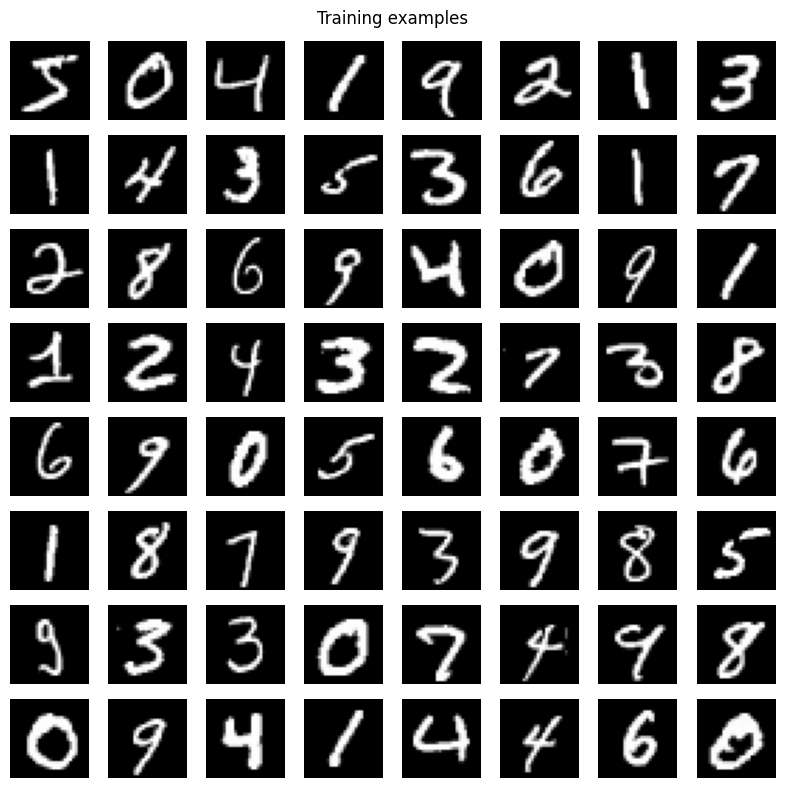

In [5]:
def downsample_28_to_14(x):
    """Average-pool 28x28 images to 14x14 without scipy/skimage."""
    if x.shape[1:] != (28, 28):
        raise ValueError("expected images with shape (n, 28, 28)")
    return x.reshape(-1, 14, 2, 14, 2).mean(axis=(2, 4))


def dequantize_mnist(x_uint8, image_size=28, center=False, rng=None, dtype=np.float32):
    """MATLAB dequantizeMNIST2018 equivalent: (raw + U[0,1)) / 256.

    The MATLAB implementation does *not* center MNIST to [-1, 1].  Keep
    center=False for parity.  The center option is left here only for experiments.
    """
    rng = np.random.default_rng() if rng is None else rng

    x = x_uint8.astype(np.float32)
    if image_size == 14:
        x = downsample_28_to_14(x)
    elif image_size == 28:
        pass
    else:
        raise ValueError("image_size must be 14 or 28 in this notebook")

    noise = rng.uniform(0.0, 1.0, size=x.shape).astype(np.float32, copy=False)
    x = (x + noise) / np.float32(256.0)

    if center:
        x = 2.0 * x - 1.0

    return x.reshape(x.shape[0], -1).astype(dtype, copy=False)


def to_display_images(x_flat, image_size=28, center=False, mode="clip"):
    """Convert flat model-space images to displayable [0, 1] images.

    mode="clip" shows the continuous dequantized sample directly.
    mode="requantized" maps the continuous dequantized value back to a
    discrete-looking MNIST pixel value for visualization.  Use likelihoods and
    reconstructions on the continuous values; requantization is display-only.
    """
    imgs = x_flat.reshape(-1, image_size, image_size)
    if center:
        imgs = (imgs + 1.0) / 2.0

    imgs = np.clip(imgs, 0.0, 1.0)
    if mode == "clip":
        return imgs
    if mode == "requantized":
        return np.floor(imgs * 256.0) / 255.0
    raise ValueError("mode must be 'clip' or 'requantized'")


def sample_diagnostics(x_flat):
    """Small diagnostics for raw inverse samples before display clipping."""
    return {
        "min": float(np.min(x_flat)),
        "max": float(np.max(x_flat)),
        "frac_below_0": float(np.mean(x_flat < 0.0)),
        "frac_above_1": float(np.mean(x_flat > 1.0)),
    }


def show_image_grid(images, n=64, title=None, cmap="gray"):
    n = min(n, len(images))
    side = int(np.ceil(np.sqrt(n)))
    plt.figure(figsize=(side, side))
    for i in range(n):
        plt.subplot(side, side, i + 1)
        plt.imshow(images[i], cmap=cmap, vmin=0.0, vmax=1.0)
        plt.axis("off")
    if title:
        plt.suptitle(title)
    plt.tight_layout()
    plt.show()


# MATLAB split: first 50k train, next 10k validation.
train_raw = x_train_uint8[:train_count]
validation_raw = x_train_uint8[train_count : train_count + validation_count]
test_raw = x_test_uint8

if train_subset is not None:
    train_raw = train_raw[:train_subset]
if valid_subset is not None:
    validation_raw = validation_raw[:valid_subset]

# Fixed validation/test dequantization, matching MATLAB seeds structurally.
# NumPy/MATLAB RNG streams are not byte-identical, but validation/test are fixed.
X_valid = dequantize_mnist(
    validation_raw,
    image_size=image_size,
    center=center_to_minus_one_one,
    rng=np.random.default_rng(1234),
)
X_test = dequantize_mnist(
    test_raw,
    image_size=image_size,
    center=center_to_minus_one_one,
    rng=np.random.default_rng(5678),
)

# Preview only. Training minibatches are freshly dequantized in the loop.
X_preview = dequantize_mnist(
    train_raw[:64],
    image_size=image_size,
    center=center_to_minus_one_one,
    rng=np.random.default_rng(seed + 1000),
)

image_shape = (image_size, image_size)
dim = image_size * image_size

print("train raw:", train_raw.shape)
print("valid fixed:", X_valid.shape, X_valid.dtype)
print("test fixed: ", X_test.shape, X_test.dtype)
print("valid min/max:", float(X_valid.min()), float(X_valid.max()))
print("dim:", dim)

show_image_grid(to_display_images(X_preview, image_size, center_to_minus_one_one, mode="requantized"), n=64, title="Training examples")


## Model

In [6]:
def odd_even_order(dim):
    """Group MATLAB/NICE odd/even vector components into contiguous halves.

    MATLAB uses 1-based oddIdx = 1:2:D and evenIdx = 2:2:D. In Python's
    0-based indexing this is [0, 2, 4, ...] followed by [1, 3, 5, ...].
    """
    return np.concatenate([np.arange(0, dim, 2), np.arange(1, dim, 2)]).astype(int)


def checkerboard_order(height, width):
    rows, cols = np.indices((height, width))
    idx = np.arange(height * width).reshape(height, width)
    mask = (rows + cols) % 2 == 0
    return np.concatenate([idx[mask].ravel(), idx[~mask].ravel()]).astype(int)


def build_nice_mnist_flow(
    image_shape,
    hidden_sizes=(128, 128),
    num_coupling_layers=4,
    prior="logistic",
    initial_partition="odd_even",
    permutation_between_layers="none",
    seed=1,
    dtype=np.float32,
):
    height, width = image_shape
    dim = height * width
    rng = np.random.default_rng(seed)

    layers = []

    if initial_partition == "odd_even":
        layers.append(Permute(odd_even_order(dim)))
    elif initial_partition == "checkerboard":
        layers.append(Permute(checkerboard_order(height, width)))
    elif initial_partition == "none":
        pass
    else:
        raise ValueError("initial_partition must be 'odd_even', 'checkerboard', or 'none'")

    for i in range(num_coupling_layers):
        layers.append(AdditiveCoupling(dim, hidden_sizes=hidden_sizes, flip=bool(i % 2), dtype=dtype))

        if i != num_coupling_layers - 1:
            if permutation_between_layers == "random":
                layers.append(Permute(rng.permutation(dim)))
            elif permutation_between_layers == "reverse":
                layers.append(Permute(np.arange(dim - 1, -1, -1)))
            elif permutation_between_layers == "none":
                pass
            else:
                raise ValueError("permutation_between_layers must be 'random', 'reverse', or 'none'")

    scaling = DiagonalScaling(dim, dtype=dtype)
    layers.append(scaling)

    model = NormalizingFlow(
        FlowSequential(layers),
        make_prior(prior, dim),
        dim=dim,
        name="MNISTNICEFlow",
    )
    model.kind = "nice"
    model.coupling = "additive"
    model.scaling = scaling
    model.initial_partition = initial_partition
    return model


def init_flow_matlab_style(model, irange=0.01, seed=1):
    """Initialize all MLP weights uniformly in [-irange, irange], biases zero."""
    rng = np.random.default_rng(seed)
    for layer in model.flow:
        if hasattr(layer, "net"):
            for dense in layer.net.layers:
                dense.W.data[...] = rng.uniform(
                    -irange, irange, size=dense.W.data.shape
                ).astype(dense.W.data.dtype, copy=False)
                if dense.b is not None:
                    dense.b.data.fill(0.0)

    if hasattr(model, "scaling"):
        model.scaling.log_s.data.fill(0.0)


np.random.seed(seed)
model = build_nice_mnist_flow(
    image_shape=image_shape,
    hidden_sizes=hidden_sizes,
    num_coupling_layers=num_coupling_layers,
    prior=prior,
    initial_partition=initial_partition,
    permutation_between_layers=permutation_between_layers,
    seed=seed,
)
init_flow_matlab_style(model, irange=init_irange, seed=seed)

n_params = sum(p.data.size for p in model.parameters())
print(model)
print("initial partition:", model.initial_partition)
print("parameter count:", f"{n_params:,}")
for i, layer in enumerate(model.flow):
    print(f"{i:02d}:", layer)


MNISTNICEFlow(dim=784, layers=6, prior=StandardLogistic(dim=784))
initial partition: odd_even
parameter count: 10,051,552
00: Permute(dim=784, perm=[0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60, 62, 64, 66, 68, 70, 72, 74, 76, 78, 80, 82, 84, 86, 88, 90, 92, 94, 96, 98, 100, 102, 104, 106, 108, 110, 112, 114, 116, 118, 120, 122, 124, 126, 128, 130, 132, 134, 136, 138, 140, 142, 144, 146, 148, 150, 152, 154, 156, 158, 160, 162, 164, 166, 168, 170, 172, 174, 176, 178, 180, 182, 184, 186, 188, 190, 192, 194, 196, 198, 200, 202, 204, 206, 208, 210, 212, 214, 216, 218, 220, 222, 224, 226, 228, 230, 232, 234, 236, 238, 240, 242, 244, 246, 248, 250, 252, 254, 256, 258, 260, 262, 264, 266, 268, 270, 272, 274, 276, 278, 280, 282, 284, 286, 288, 290, 292, 294, 296, 298, 300, 302, 304, 306, 308, 310, 312, 314, 316, 318, 320, 322, 324, 326, 328, 330, 332, 334, 336, 338, 340, 342, 344, 346, 348, 350, 352, 354, 356, 358, 360, 3

In [7]:
z, logdet = model.forward(X_preview[:10])
x_roundtrip = model.inverse(z).data
max_abs_error = np.max(np.abs(x_roundtrip - X_preview[:10]))

print("z shape:", z.data.shape)
print("logdet shape:", logdet.data.shape)
print("logdet:", logdet.data)
print("max |inverse(forward(x)) - x|:", max_abs_error)
print("initial preview NLL:", model.nll(X_preview[:64]).item())


z shape: (10, 784)
logdet shape: ()
logdet: 0.0
max |inverse(forward(x)) - x|: 2.3283064e-10
initial preview NLL: 1107.27685546875


## Training helpers

Shared helpers such as `save_state`, `load_state`, `full_nll`, `grad_global_norm`, and `clip_grad_norm` are imported from `vect_micrograd.utils`; MNIST-specific metrics remain below.


In [8]:
def continuous_bits_per_dim_from_model_nll(nll, dim, center=False):
    # If u in [0, 1] is transformed to x = 2u - 1, then
    # log p_u(u) = log p_x(x) + dim * log(2).  MATLAB parity uses center=False.
    scale_correction = dim * np.log(2.0) if center else 0.0
    return (nll - scale_correction) / (dim * np.log(2.0))


def check_finite_loss(loss):
    loss_value = loss.item()
    if not np.isfinite(loss_value):
        raise FloatingPointError(f"non-finite loss: {loss_value}")
    return loss_value


## Train

In [9]:
loss_history = []
valid_history = []
grad_norm_history = []

params = list(model.parameters())
num_train = len(train_raw)
steps_per_epoch = int(np.ceil(num_train / batch_size))
total_steps = epochs * steps_per_epoch

optimizer = RMSProp(
    params,
    lr=learning_rate,
    total_steps=total_steps,
    rho=rmsprop_rho,
    eps=rmsprop_eps,
    weight_decay=rmsprop_weight_decay,
    min_lr=min_learning_rate,
    lr_decay_factor=lr_decay_factor,
    eps_mode=rmsprop_eps_mode,
    momentum=init_momentum,
)

print(
    optimizer.__class__.__name__,
    {
        "lr": learning_rate,
        "min_lr": min_learning_rate,
        "lr_schedule": f"lr / ({lr_decay_factor} ** step), floored at min_lr",
        "momentum_schedule": (
            f"{init_momentum} until epoch {momentum_start_epoch - 1}; "
            f"linear ramp over [{momentum_start_epoch}, {momentum_saturate_epoch}); "
            f"{final_momentum} from epoch {momentum_saturate_epoch}"
        ),
        "rho": rmsprop_rho,
        "eps": rmsprop_eps,
        "eps_mode": rmsprop_eps_mode,
        "steps_per_epoch": steps_per_epoch,
        "initial_partition": initial_partition,
        "domain": "[0,1)" if not center_to_minus_one_one else "[-1,1]",
        "train/valid": (len(train_raw), len(validation_raw)),
        "fresh_dequantization_per_minibatch": True,
    },
)

best_valid_nll = float("inf")
best_state = None
best_step = None

global_step = 0
rng_train = np.random.default_rng(seed)

for epoch in range(1, epochs + 1):
    momentum_coeff = epoch_momentum(
        epoch,
        init_momentum=init_momentum,
        final_momentum=final_momentum,
        start_epoch=momentum_start_epoch,
        saturate_epoch=momentum_saturate_epoch,
    )

    if batch_size >= num_train:
        order = np.arange(num_train)
    else:
        order = rng_train.permutation(num_train)

    epoch_loss_sum = 0.0
    epoch_seen = 0

    for start in range(0, num_train, batch_size):
        idx = order[start : start + batch_size]
        xb = dequantize_mnist(
            train_raw[idx],
            image_size=image_size,
            center=center_to_minus_one_one,
            rng=rng_train,
        )

        optimizer.zero_grad()

        loss = model.nll(xb)
        loss_value = check_finite_loss(loss) if abort_on_non_finite else loss.item()
        loss.backward()

        if use_grad_clip and np.isfinite(max_grad_norm):
            grad_norm = clip_grad_norm(params, max_norm=max_grad_norm)
        else:
            grad_norm = grad_global_norm(params, fail_on_non_finite=abort_on_non_finite)

        optimizer.step(global_step, momentum=momentum_coeff)

        loss_history.append(loss_value)
        grad_norm_history.append(grad_norm)
        epoch_loss_sum += loss_value * len(xb)
        epoch_seen += len(xb)

        if global_step % log_every_steps == 0:
            print(
                f"epoch {epoch:4d}/{epochs:4d} step {global_step:7d}/{total_steps:7d} | "
                f"minibatch LL {-loss_value:9.4f} | "
                f"lr {optimizer.current_lr:.5g} | "
                f"mom {optimizer.current_momentum:.3f} | "
                f"grad {grad_norm:9.3e}"
            )

        global_step += 1

    if epoch % validation_every_epochs == 0 or epoch == epochs:
        current_valid_nll = full_nll(model, X_valid, batch_size=batch_size)
        current_valid_bpd = continuous_bits_per_dim_from_model_nll(
            current_valid_nll,
            dim=dim,
            center=center_to_minus_one_one,
        )
        mean_epoch_nll = epoch_loss_sum / epoch_seen
        valid_history.append((global_step, current_valid_nll, current_valid_bpd))

        if current_valid_nll < best_valid_nll:
            best_valid_nll = current_valid_nll
            best_state = save_state(model)
            best_step = global_step

        print(
            f"epoch {epoch:4d}/{epochs:4d} done | "
            f"train LL {-mean_epoch_nll:9.4f} | "
            f"valid LL {-current_valid_nll:9.4f} | "
            f"valid bpd {current_valid_bpd:7.4f} | best step {best_step}"
        )

if restore_best_model and best_state is not None:
    load_state(model, best_state)
    print(
        f"Restored best validation model from step {best_step} "
        f"with LL {-best_valid_nll:.4f}"
    )


RMSProp {'lr': 0.001, 'min_lr': 0.0001, 'lr_schedule': 'lr / (1.0005 ** step), floored at min_lr', 'momentum_schedule': '0.0 until epoch 4; linear ramp over [5, 6); 0.5 from epoch 6', 'rho': 0.95, 'eps': 0.01, 'eps_mode': 'max', 'steps_per_epoch': 250, 'initial_partition': 'odd_even', 'domain': '[0,1)', 'train/valid': (50000, 10000), 'fresh_dequantization_per_minibatch': True}


epoch    1/ 250 step       0/  62500 | minibatch LL -1108.1122 | lr 0.001 | mom 0.000 | grad 2.689e+01
epoch    1/ 250 step      50/  62500 | minibatch LL -1046.5214 | lr 0.00097532 | mom 0.000 | grad 2.702e+01
epoch    1/ 250 step     100/  62500 | minibatch LL -1009.9074 | lr 0.00095124 | mom 0.000 | grad 2.691e+01
epoch    1/ 250 step     150/  62500 | minibatch LL -974.3736 | lr 0.00092776 | mom 0.000 | grad 2.683e+01
epoch    1/ 250 step     200/  62500 | minibatch LL -940.9216 | lr 0.00090486 | mom 0.000 | grad 2.668e+01
epoch    1/ 250 done | train LL -995.1690 | valid LL -907.2708 | valid bpd  1.6695 | best step 250
epoch    2/ 250 step     250/  62500 | minibatch LL -908.2266 | lr 0.00088252 | mom 0.000 | grad 2.654e+01
epoch    2/ 250 step     300/  62500 | minibatch LL -874.6290 | lr 0.00086074 | mom 0.000 | grad 2.653e+01
epoch    2/ 250 step     350/  62500 | minibatch LL -844.2852 | lr 0.00083949 | mom 0.000 | grad 2.632e+01
epoch    2/ 250 step     400/  62500 | minibatc

## Diagnostics

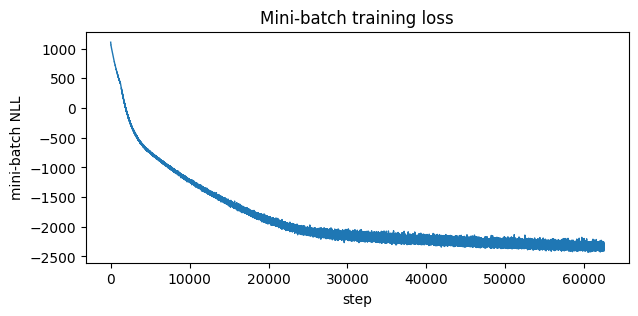

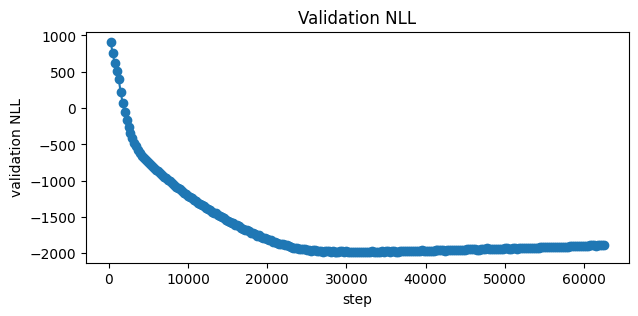

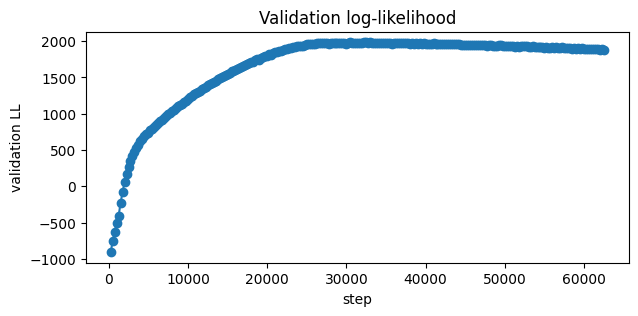

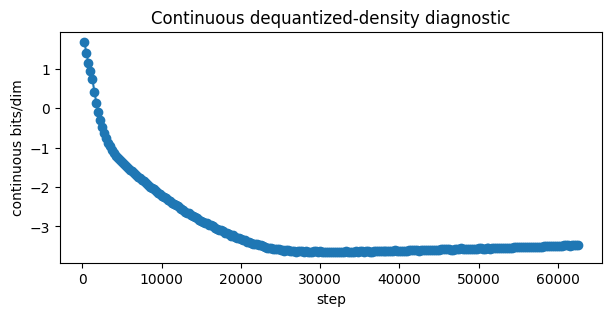

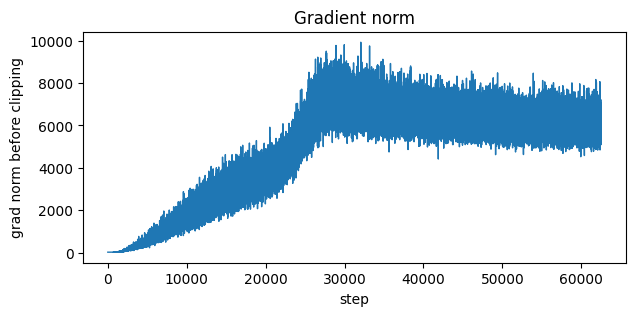

In [10]:
plt.figure(figsize=(7, 3))
plt.plot(loss_history, linewidth=1)
plt.xlabel("step")
plt.ylabel("mini-batch NLL")
plt.title("Mini-batch training loss")
plt.show()

if valid_history:
    steps_eval, valid_nll, valid_bpd = zip(*valid_history)

    plt.figure(figsize=(7, 3))
    plt.plot(steps_eval, valid_nll, marker="o")
    plt.xlabel("step")
    plt.ylabel("validation NLL")
    plt.title("Validation NLL")
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(steps_eval, [-v for v in valid_nll], marker="o")
    plt.xlabel("step")
    plt.ylabel("validation LL")
    plt.title("Validation log-likelihood")
    plt.show()

    plt.figure(figsize=(7, 3))
    plt.plot(steps_eval, valid_bpd, marker="o")
    plt.xlabel("step")
    plt.ylabel("continuous bits/dim")
    plt.title("Continuous dequantized-density diagnostic")
    plt.show()

if grad_norm_history:
    plt.figure(figsize=(7, 3))
    plt.plot(grad_norm_history, linewidth=1)
    plt.xlabel("step")
    plt.ylabel("grad norm before clipping")
    plt.title("Gradient norm")
    plt.show()


## Samples and reconstruction check

sample diagnostics before display clipping: {'min': -0.46684569120407104, 'max': 1.3588950634002686, 'frac_below_0': 0.19724569515306123, 'frac_above_1': 0.011399872448979591}


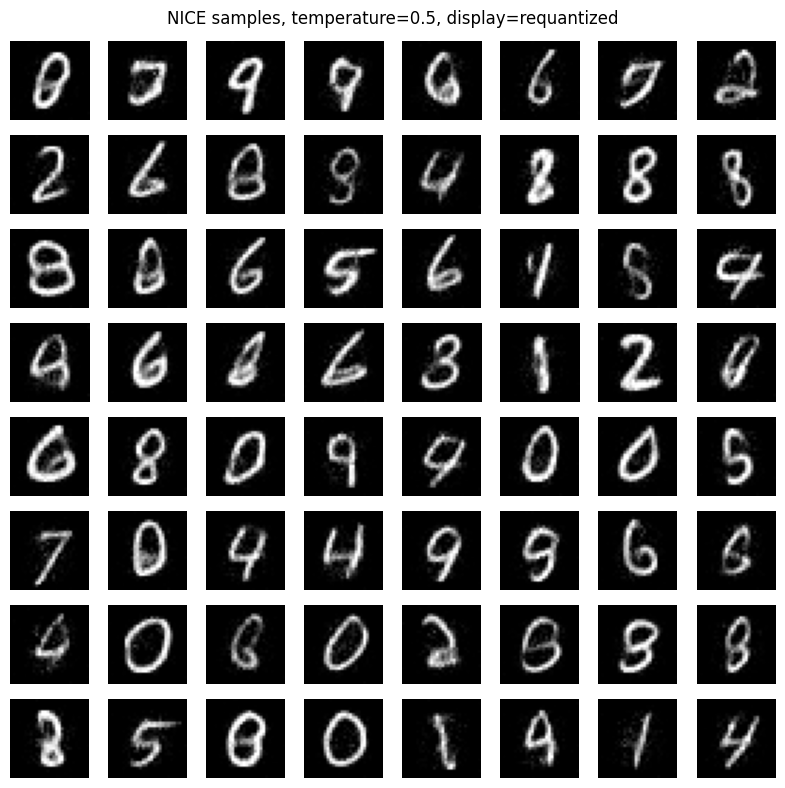

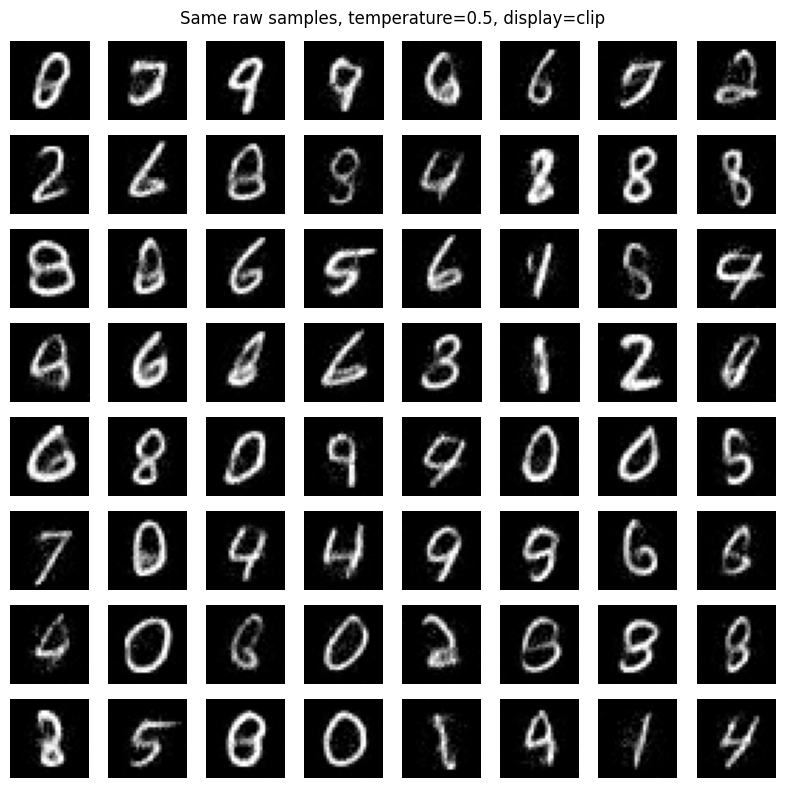

In [11]:
# Visualization.
n_sample_images = 64
# NICE models a continuous dequantized density.  For human-readable MNIST
# samples, lower latent temperatures and requantized display often look less
# grainy.  This does not change likelihood evaluation.
sample_temperature = 0.5
sample_display_mode = "requantized"  # "clip" or "requantized"

samples = model.sample(n_sample_images, temperature=sample_temperature)
print("sample diagnostics before display clipping:", sample_diagnostics(samples))

sample_images = to_display_images(
    samples,
    image_size=image_size,
    center=center_to_minus_one_one,
    mode=sample_display_mode,
)
show_image_grid(
    sample_images,
    n=n_sample_images,
    title=f"NICE samples, temperature={sample_temperature}, display={sample_display_mode}",
)

if sample_display_mode != "clip":
    direct_sample_images = to_display_images(
        samples,
        image_size=image_size,
        center=center_to_minus_one_one,
        mode="clip",
    )
    show_image_grid(
        direct_sample_images,
        n=n_sample_images,
        title=f"Same raw samples, temperature={sample_temperature}, display=clip",
    )


max reconstruction error: 2.2947788e-06
latent mean/std: 0.069368377327919 4.854709148406982
validation NLL: -1984.9749926757813
test NLL: -1993.2882836914061


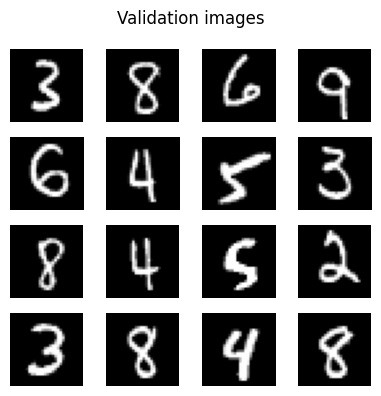

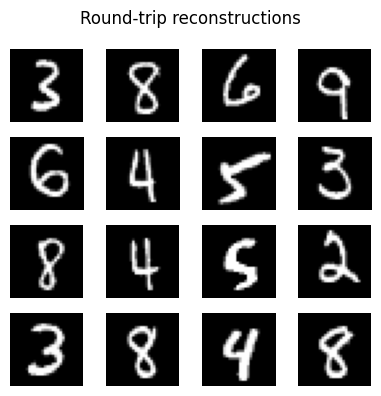

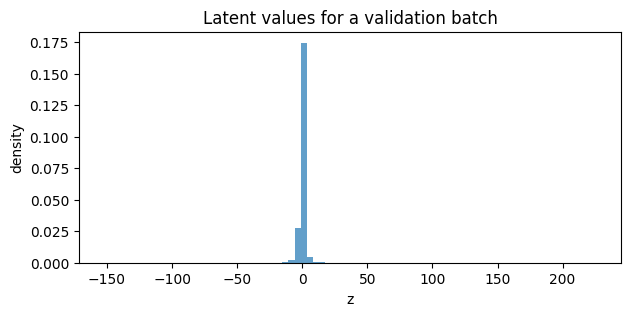

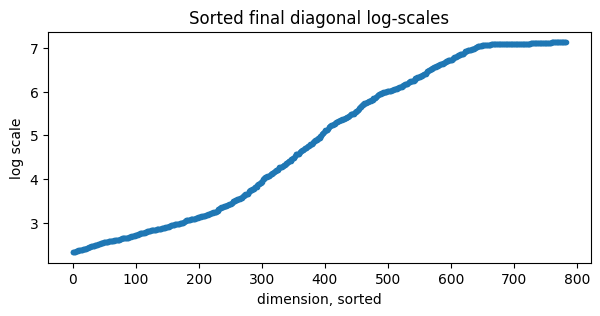

In [12]:
n_show = 16
x_batch = X_valid[:n_show]
z_batch, _ = model.forward(x_batch)
x_recon = model.inverse(z_batch).data

print("max reconstruction error:", np.max(np.abs(x_recon - x_batch)))
print("latent mean/std:", float(z_batch.data.mean()), float(z_batch.data.std()))
print("validation NLL:", full_nll(model, X_valid, batch_size=batch_size))
print("test NLL:", full_nll(model, X_test, batch_size=batch_size))

show_image_grid(to_display_images(x_batch, image_size, center_to_minus_one_one, mode="requantized"), n=n_show, title="Validation images")
show_image_grid(to_display_images(x_recon, image_size, center_to_minus_one_one, mode="requantized"), n=n_show, title="Round-trip reconstructions")

plt.figure(figsize=(7, 3))
plt.hist(z_batch.data.ravel(), bins=80, density=True, alpha=0.7)
plt.title("Latent values for a validation batch")
plt.xlabel("z")
plt.ylabel("density")
plt.show()

if hasattr(model, "scaling"):
    plt.figure(figsize=(7, 3))
    plt.plot(np.sort(model.scaling.log_s.data), marker=".", linewidth=1)
    plt.title("Sorted final diagonal log-scales")
    plt.xlabel("dimension, sorted")
    plt.ylabel("log scale")
    plt.show()


## Inpainting

outer=00  iteration=000000/111895  lr=0.0990099  mean_ll=-85563.109
outer=01  iteration=000001/111895  lr=0.0990099  mean_ll=-183812.484
outer=02  iteration=000005/111895  lr=0.0952381  mean_ll=-123817.211
outer=03  iteration=000014/111895  lr=0.0877193  mean_ll=-102435.008
outer=04  iteration=000030/111895  lr=0.0769231  mean_ll=-87667.359
outer=05  iteration=000055/111895  lr=0.0645161  mean_ll=-67429.648
outer=06  iteration=000091/111895  lr=0.052356  mean_ll=-50147.469
outer=07  iteration=000140/111895  lr=0.0416667  mean_ll=-37670.988
outer=08  iteration=000204/111895  lr=0.0328947  mean_ll=-27772.564
outer=09  iteration=000285/111895  lr=0.025974  mean_ll=-20463.211
outer=10  iteration=000385/111895  lr=0.0206186  mean_ll=-15418.246
outer=11  iteration=000506/111895  lr=0.0165017  mean_ll=-11420.207
outer=12  iteration=000650/111895  lr=0.0133333  mean_ll=-8751.767
outer=13  iteration=000819/111895  lr=0.0108814  mean_ll=-6366.820
outer=14  iteration=001015/111895  lr=0.00896861 

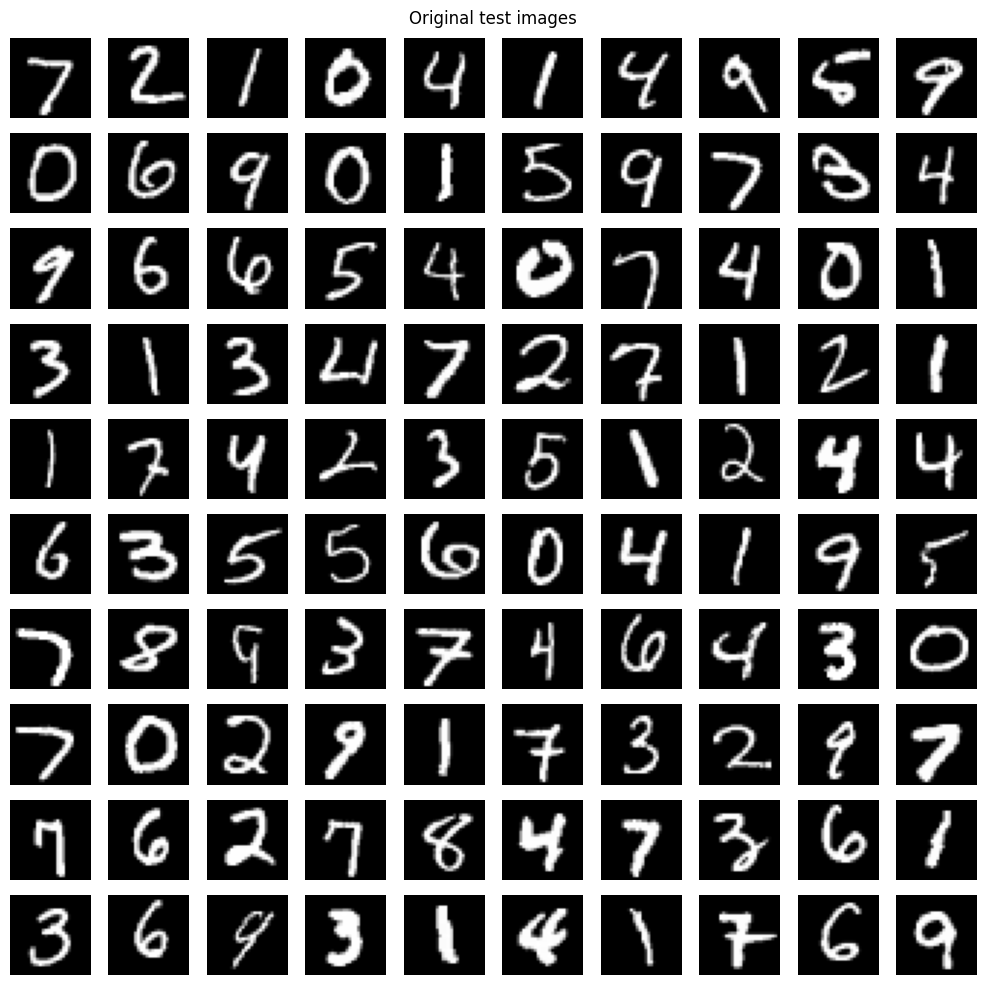

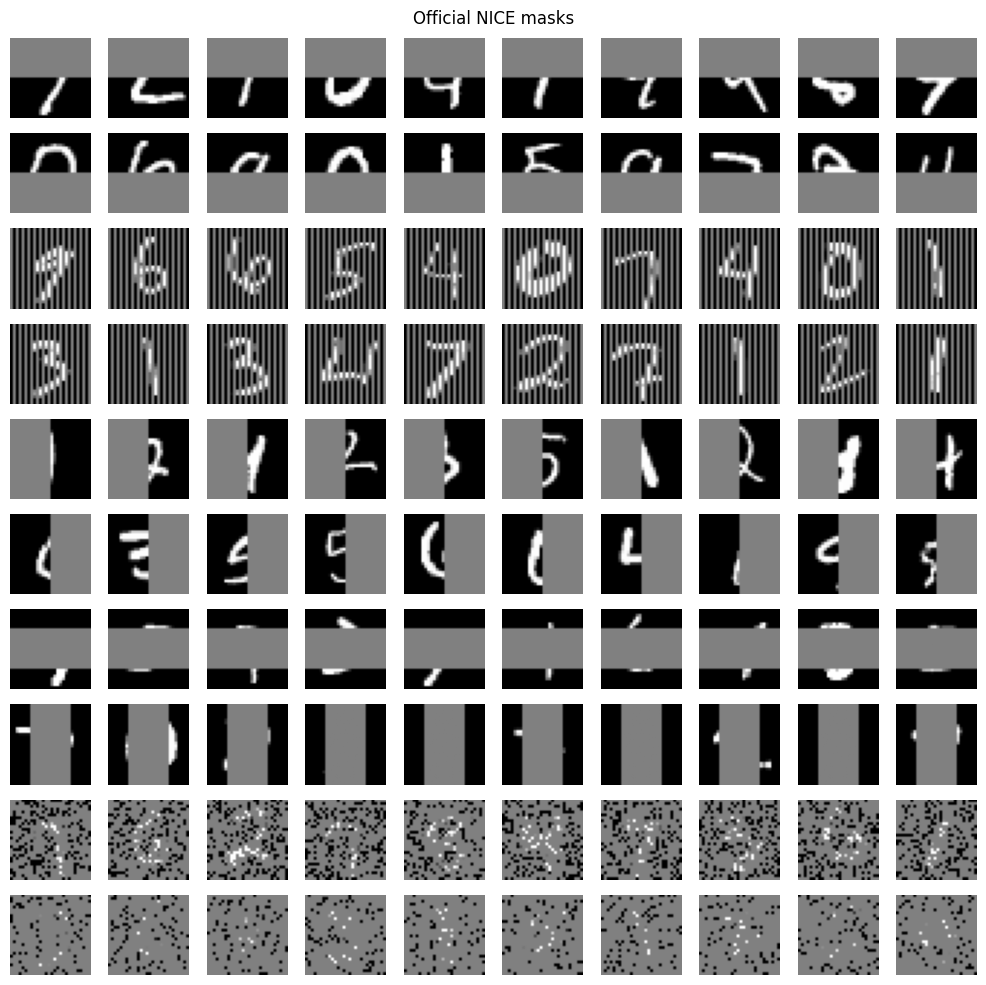

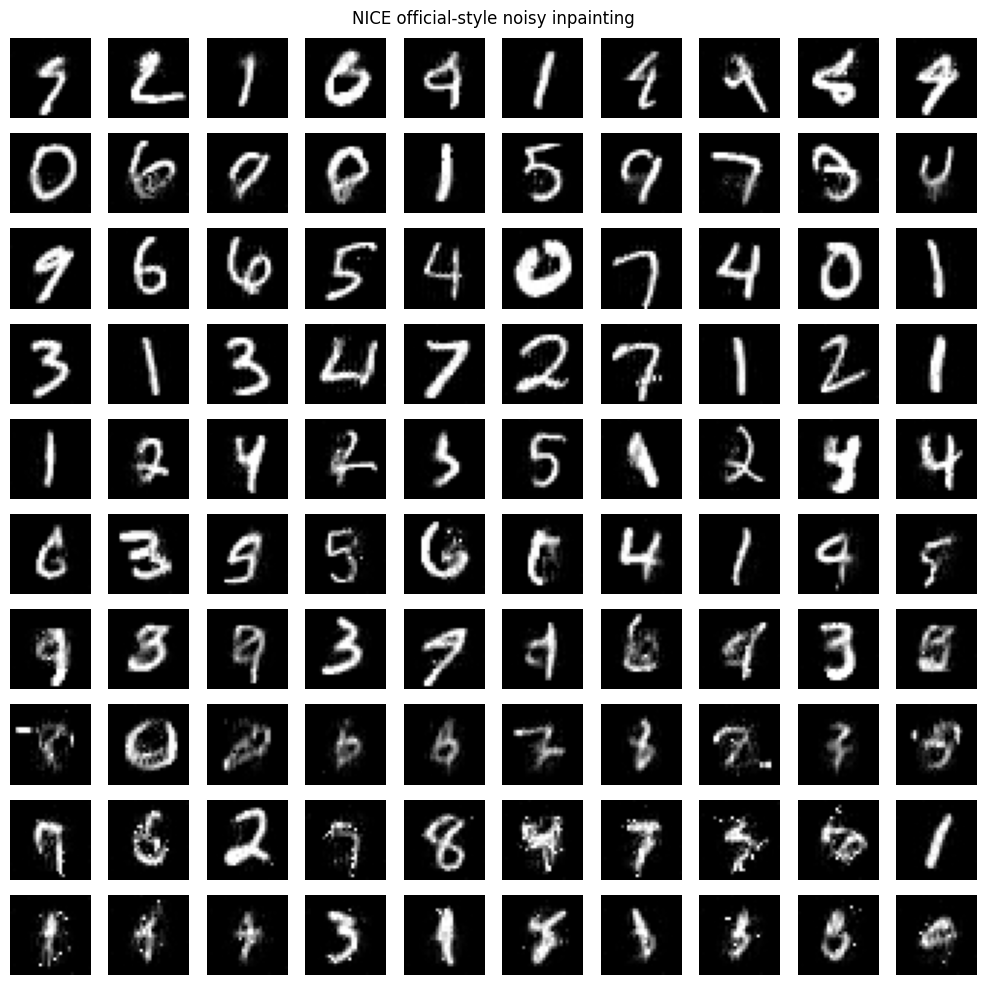

In [13]:
# ---------------------------------------------------------------------
# NICE-paper-style MNIST inpainting
# Based closely on laurent-dinh/nice:
# pylearn2/scripts/reconstruct_mnist_gif.py
#
# Key differences from our previous attempts:
#   - no ADAM
#   - no latent optimization
#   - no deterministic MAP
#   - noisy gradient ascent on log likelihood
#   - observed pixels overwritten after every step
#   - learning rate lr = 1 / (0.1 * iteration + 10)
# ---------------------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from vect_micrograd.vect_engine import Value


def freeze_parameters(params):
    old_flags = [p.requires_grad for p in params]
    old_grads = [p.grad for p in params]

    for p in params:
        p.requires_grad = False
        p.grad = None

    return old_flags, old_grads


def restore_parameters(params, old_flags, old_grads):
    for p, flag, grad in zip(params, old_flags, old_grads):
        p.requires_grad = flag
        p.grad = grad


def mnist_float_for_inpainting(x_uint8, image_size=28):
    """
    Official Pylearn2 MNIST inpainting uses test_set.get_batch_design(),
    i.e. floating MNIST design matrix in [0, 1].

    Use this if your notebook has raw uint8 MNIST images.
    """
    x = x_uint8.astype(np.float32)

    if image_size == 14:
        x = downsample_28_to_14(x)
    elif image_size != 28:
        raise ValueError("image_size must be 14 or 28")

    # Simpler Pylearn2-style scaling.
    # If your model was trained with (x + 0.5)/256, replace this line by:
    # x = (x + 0.5) / 256.0
    x = x / 255.0

    return x.reshape(x.shape[0], -1).astype(np.float32, copy=False)


def make_official_nice_100_masks(image_size=28, seed=0):
    """
    Reproduce the 100-example mask layout from the official script.

    observed_mask == True  means observed/fixed pixel.
    observed_mask == False means missing/inpainted pixel.

    For 28x28, the groups are:
      0:10    top half missing
      10:20   bottom half missing
      20:30   even-indexed flat pixels missing
      30:40   odd-indexed flat pixels missing
      40:50   left half missing
      50:60   right half missing
      60:70   middle horizontal band missing
      70:80   middle vertical band missing
      80:90   random observed p=0.25
      90:100  random observed p=0.10
    """
    if image_size != 28:
        raise ValueError("This exact official mask layout assumes 28x28 MNIST.")

    rng = np.random.default_rng(seed)

    n_examples = 100
    dim = image_size * image_size

    m = np.ones((n_examples, dim), dtype=bool)

    # Official:
    # m_val[:10, :392] = 0
    # m_val[10:20, 392:] = 0
    m[0:10, :392] = False
    m[10:20, 392:] = False

    # Official:
    # m_val[20:30, ::2] = 0
    # m_val[30:40, 1::2] = 0
    m[20:30, ::2] = False
    m[30:40, 1::2] = False

    # Official left/right masks.
    for i in range(28):
        # m_val[40:50, (i*28):((2*i+1)*14)] = 0
        m[40:50, i * 28 : i * 28 + 14] = False

        # m_val[50:60, ((2*i+1)*14):((i+1)*28)] = 0
        m[50:60, i * 28 + 14 : (i + 1) * 28] = False

    # Official:
    # m_val[60:70, 196:588] = 0
    # 196 = 7*28, 588 = 21*28
    m[60:70, 196:588] = False

    # Official middle vertical mask.
    for i in range(28):
        # m_val[70:80, ((4*i+1)*7):((4*i+3)*7)] = 0
        # This is cols 7:21 in each row.
        m[70:80, i * 28 + 7 : i * 28 + 21] = False

    # Official random masks:
    # m_val[80:90] = np.random.binomial(n=1, p=.25, size=(10,784))
    # m_val[90:]   = np.random.binomial(n=1, p=.1,  size=(10,784))
    m[80:90] = rng.binomial(n=1, p=0.25, size=(10, dim)).astype(bool)
    m[90:100] = rng.binomial(n=1, p=0.10, size=(10, dim)).astype(bool)

    return m


def make_single_official_style_mask(image_size=28, kind="bottom", seed=0):
    """
    Convenience version for a single mask type.
    Same convention:
        True  = observed/fixed
        False = missing/inpainted
    """
    if image_size != 28:
        raise ValueError("This version assumes 28x28 MNIST.")

    rng = np.random.default_rng(seed)
    m = np.ones((image_size, image_size), dtype=bool)

    if kind == "top":
        # Missing top half.
        m[:14, :] = False

    elif kind == "bottom":
        # Missing bottom half.
        m[14:, :] = False

    elif kind == "left":
        m[:, :14] = False

    elif kind == "right":
        m[:, 14:] = False

    elif kind == "middle_horizontal":
        # Official: rows 7:21 missing.
        m[7:21, :] = False

    elif kind == "middle_vertical":
        # Official: cols 7:21 missing.
        m[:, 7:21] = False

    elif kind == "even_pixels":
        flat = m.reshape(-1)
        flat[::2] = False
        return flat

    elif kind == "odd_pixels":
        flat = m.reshape(-1)
        flat[1::2] = False
        return flat

    elif kind == "random75":
        # 25% observed, 75% missing.
        return rng.binomial(n=1, p=0.25, size=image_size * image_size).astype(bool)

    elif kind == "random90":
        # 10% observed, 90% missing.
        return rng.binomial(n=1, p=0.10, size=image_size * image_size).astype(bool)

    else:
        raise ValueError(f"Unknown mask kind: {kind}")

    return m.reshape(-1)


def nice_official_style_inpaint(
    model,
    x_true,
    observed_mask,
    sqrt_iter=70,
    seed=0,
    noise_scale=1.0,
    clip_pixels=False,
    verbose=True,
    store_every_outer=True,
):
    """
    Faithful port of the official NICE inpainting dynamics.

    Official structure:

        X_shared initialized Uniform(0, 1)
        X_shared[observed] = x_true[observed]

        for i in range(70):
            for j in range(i**2):
                lr = 1 / (0.1 * iteration + 10)
                X_shared += lr * (grad log p(X_complete) + Normal(0, 1))
                X_shared[observed] = x_true[observed]

    Parameters
    ----------
    model:
        Trained NICE model with model.log_prob(Value(...)).
    x_true:
        Array of shape (n, 784), values in [0, 1].
    observed_mask:
        Either shape (784,) or shape (n, 784).
        True = observed/fixed.
        False = missing/inpainted.
    sqrt_iter:
        Official value is 70.
        Total updates = sum_{i=0}^{sqrt_iter-1} i^2.
        For 70 this is 111895 updates.
    noise_scale:
        Official value is 1.0.
    clip_pixels:
        Official script does not explicitly clip after each update.
        Set True only if values explode in this Python implementation.
    """
    rng = np.random.default_rng(seed)

    x_true = x_true.astype(np.float32, copy=True)
    n, dim = x_true.shape

    if observed_mask.ndim == 1:
        observed_mask = np.broadcast_to(observed_mask.reshape(1, -1), (n, dim)).copy()
    else:
        observed_mask = observed_mask.astype(bool, copy=True)

    missing_mask = ~observed_mask

    # Official: X_shared initialized uniform.
    x_shared = rng.uniform(0.0, 1.0, size=(n, dim)).astype(np.float32)

    # Official: observed pixels initialized from data.
    x_shared[observed_mask] = x_true[observed_mask]

    params = list(model.parameters())
    old_flags, old_grads = freeze_parameters(params)

    frames = []
    ll_history = []

    iteration = 0
    max_iter = int(np.sum(np.arange(sqrt_iter) ** 2))

    try:
        for outer in range(sqrt_iter):
            n_inner = outer ** 2

            for _ in range(n_inner):
                # In the official Theano code:
                #   X_complete = where(M, X, X_shared)
                # Since we overwrite observed pixels every step, x_shared
                # already equals X_complete.
                x_val = Value(x_shared, requires_grad=True)

                ll = model.log_prob(x_val)
                objective = ll.mean()
                objective.backward()

                grad = x_val.grad.astype(np.float32, copy=False)

                # Only update missing pixels.
                grad[observed_mask] = 0.0

                lr = 1.0 / (0.1 * iteration + 10.0)

                noise = rng.standard_normal(size=x_shared.shape).astype(np.float32)
                noise[observed_mask] = 0.0

                # Official noisy gradient ascent.
                x_shared = x_shared + lr * (grad + noise_scale * noise)

                # Official: updates[X_shared] = where(M, X, updates[X_shared])
                x_shared[observed_mask] = x_true[observed_mask]

                if clip_pixels:
                    np.clip(x_shared, 0.0, 1.0, out=x_shared)
                    x_shared[observed_mask] = x_true[observed_mask]

                iteration += 1

            # Evaluate and optionally store frame after each outer loop.
            x_eval = Value(x_shared, requires_grad=False)
            ll_mean = float(model.log_prob(x_eval).data.mean())
            ll_history.append(ll_mean)

            if store_every_outer:
                frames.append(x_shared.copy())

            if verbose:
                print(
                    f"outer={outer:02d}  "
                    f"iteration={iteration:06d}/{max_iter}  "
                    f"lr={1.0 / (0.1 * max(iteration, 1) + 10.0):.6g}  "
                    f"mean_ll={ll_mean:.3f}"
                )

    finally:
        restore_parameters(params, old_flags, old_grads)

    return x_shared.copy(), ll_history, frames


# ---------------------------------------------------------------------
# Option A: reproduce the official 100-image inpainting layout
# ---------------------------------------------------------------------

image_size = 28
n_examples = 100

x_inpaint = mnist_float_for_inpainting(
    test_raw[:n_examples],
    image_size=image_size,
)

official_masks = make_official_nice_100_masks(
    image_size=image_size,
    seed=75,
)

x_masked = x_inpaint.copy()
x_masked[~official_masks] = 0.5

x_recon, ll_history, frames = nice_official_style_inpaint(
    model=model,
    x_true=x_inpaint,
    observed_mask=official_masks,
    sqrt_iter=70,          # official value
    seed=123,
    noise_scale=1.0,       # official value
    clip_pixels=False,     # official script does not clip
    verbose=True,
    store_every_outer=False,
)

# For visualization only, clip to [0,1].
x_recon_display = np.clip(x_recon, 0.0, 1.0)

show_image_grid(
    to_display_images(x_inpaint, image_size, center=False, mode="clip"),
    n=100,
    title="Original test images",
)

show_image_grid(
    to_display_images(x_masked, image_size, center=False, mode="clip"),
    n=100,
    title="Official NICE masks",
)

show_image_grid(
    to_display_images(x_recon_display, image_size, center=False, mode="clip"),
    n=100,
    title="NICE official-style noisy inpainting",
)